# Escape Probability RT + Monte Carlo two-level iteration

This notebook follows the same setup as the DISORT and RT_spherical examples, but uses a uniform static sphere escape-probability update. Each coma layer is approximated as a homogeneous sphere, with local mean intensity `J_nu = (1 - beta) S_nu + beta J_background`.


In [1]:
import sys
sys.path.append('../')


In [2]:
import csv

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

import Constants as constants
from ComaGrid import ComaGrid
from Einstein_coeff import einstein_coeffs_B
from Electron_collision import electron_collision_rate
from Molecular_collision import detailed_balance_excitation_rate, molecular_collision_rate
from profiles import calc_density, temperature_inverse_distance, electron_biver_1997, velocity_tanh
from Solar_pumping import scale_g_factors_from_1au
from Statistical_equilibrium import monte_carlo_two_level_populations
from escape_probability_RTsolver import solve_escape_probability_layers


In [3]:
data_path = '../data/r_lev0_2.5au.csv'
profile = np.loadtxt(data_path, delimiter=',')
radius_km = profile[::-1, 0]

# Keep the same outer-to-inner ordering used by the spherical RT example.
sort_order = np.argsort(radius_km)[::-1]
radius_km = radius_km[sort_order]
level0_ratio = np.ones_like(radius_km)
level1_ratio = 1.0 - level0_ratio


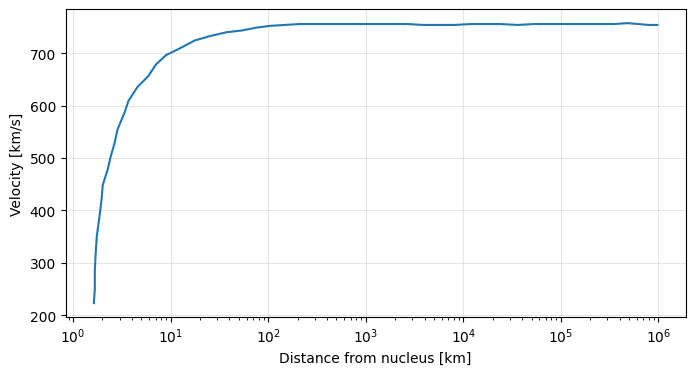

In [4]:
rkm = []
velocity_km_s = []
with open('../vel25au.csv', 'r') as csvfile:
    reader = csv.reader(csvfile)
    for row in reader:
        rkm.append(float(row[0]))
        velocity_km_s.append(float(row[1]))

rkm = np.array(rkm)
velocity_km_s = np.array(velocity_km_s)

plt.figure(figsize=(8, 4))
plt.semilogx(rkm, velocity_km_s, color='tab:blue')
plt.xlabel('Distance from nucleus [km]')
plt.ylabel('Velocity [km/s]')
plt.grid(True, alpha=0.3)
plt.show()


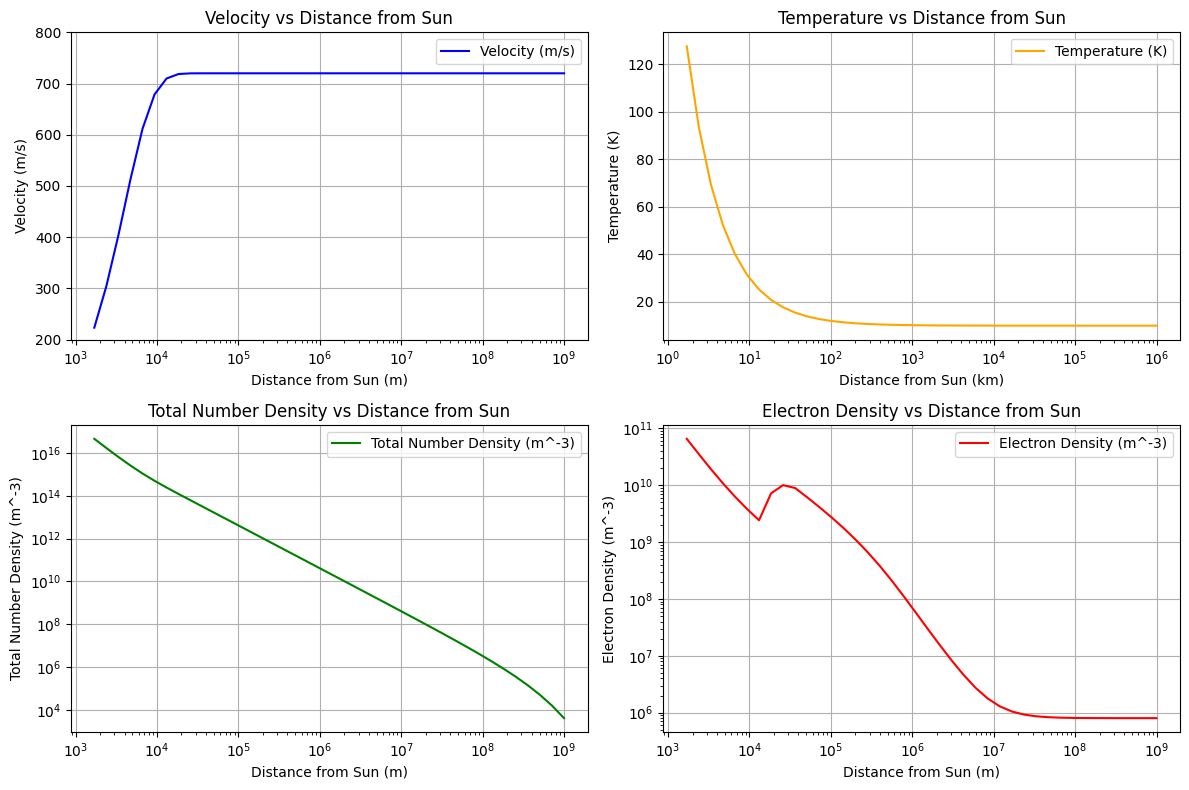

In [14]:
# Transition parameters
nu_Hz = 556.936e9
A_ul_s_1 = 3.456e-3
g_u = 9.0
g_l = 9.0
absorber_mass_kg = 18.01528 * constants.ATOMIC_MASS_UNIT

# Coma setup matching examples/coma.ipynb
heliocentric_distance_AU = 2.5
xc = np.logspace(np.log10(1.7e3), np.log10(1e9), 40)[::-1]
xf = np.empty(xc.size + 1, dtype=np.float64)
xf[1:-1] = np.sqrt(xc[:-1] * xc[1:])
xf[0] = xc[0] ** 2 / xf[1]
xf[-1] = xc[-1] ** 2 / xf[-2]
nlayer = xc.size

v0 = 720.0
c_scale = 5.3e3
velocity = velocity_tanh(xc, v0=v0, c=c_scale)
# velocity = np.interp(xc, rkm*1e3, velocity)

T0 = 10.0
temperature = temperature_inverse_distance(xc, a=10, b=1, t0=T0, r0=2000)

Q = 3.7e26
total_number_density = calc_density(
    Q,
    xc,
    velocity,
    r_h=heliocentric_distance_AU,
    model_type='isotropic',
    photo_dissociation=True,
)
nelec, telec = electron_biver_1997(
    Q,
    r_h=heliocentric_distance_AU,
    r=xc,
    v=velocity,
    t_kin=temperature,
    t_emax=10000,
)

# Initial level ratios: rL0 = 0.5, rL1 = 0.5
fractions = np.zeros((nlayer, 1), dtype=np.float64)
fractions[:, 0] = 0.0# level1_ratio
coma = ComaGrid(
    temperature=temperature,
    total_number_density=total_number_density,
    velocity=velocity,
    nelec=nelec,
    telec=telec,
    fractions=fractions,
)

coma.xf = xf
coma.xc = xc


# plot the profiles
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.semilogx(xc, velocity, label='Velocity (m/s)', color='blue')
plt.xlabel('Distance from Sun (m)')
plt.ylabel('Velocity (m/s)')
plt.ylim(200, 800)
plt.title('Velocity vs Distance from Sun')
plt.grid()
plt.legend()    
plt.subplot(2, 2, 2)
plt.semilogx(xc/1000, temperature, label='Temperature (K)', color='orange')
plt.xlabel('Distance from Sun (km)')
plt.ylabel('Temperature (K)')
plt.title('Temperature vs Distance from Sun')
plt.grid()
plt.legend()
plt.subplot(2, 2, 3)
plt.loglog(xc, total_number_density, label='Total Number Density (m^-3)', color='green')
plt.xlabel('Distance from Sun (m)')
plt.ylabel('Total Number Density (m^-3)')
plt.title('Total Number Density vs Distance from Sun')
plt.grid()
plt.legend()
plt.subplot(2, 2, 4)
plt.loglog(xc, nelec, label='Electron Density (m^-3)', color='red')
plt.xlabel('Distance from Sun (m)')
plt.ylabel('Electron Density (m^-3)')
plt.title('Electron Density vs Distance from Sun')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()






In [6]:
B_ul_SI, B_lu_SI = einstein_coeffs_B(
    nu_Hz=nu_Hz,
    A_ul_s_1=A_ul_s_1,
    g_u=g_u,
    g_l=g_l,
)

Cm_ul_s_1 = np.asarray(
    molecular_collision_rate(coma.total_number_density, coma.temperature),
    dtype=np.float64,
)
Cm_lu_s_1 = np.asarray(
    detailed_balance_excitation_rate(
        Cm_ul_s_1,
        coma.temperature,
        nu_Hz=nu_Hz,
        g_u=g_u,
        g_l=g_l,
    ),
    dtype=np.float64,
)

electron_rates = np.array([
    electron_collision_rate(
        n_e=float(n_e),
        t_e=float(t_e),
        nu_Hz=nu_Hz,
        A_ul_s_1=A_ul_s_1,
        g_u=g_u,
        g_l=g_l,
    )
    for n_e, t_e in zip(coma.nelec, coma.telec)
], dtype=np.float64)
Ce_ul_s_1 = electron_rates[:, 0]
Ce_lu_s_1 = electron_rates[:, 1]

G_ul_s_1, G_lu_s_1 = scale_g_factors_from_1au(heliocentric_distance_AU)
G_ul_s_1 = np.full(nlayer, G_ul_s_1, dtype=np.float64)
G_lu_s_1 = np.full(nlayer, G_lu_s_1, dtype=np.float64)

print('Heliocentric distance [AU]:', heliocentric_distance_AU)
print('Production rate Q [s^-1]:', Q)
print('Initial lower-level density:', coma.density[:, 0])
print('Initial upper-level density:', coma.density[:, 1])


Heliocentric distance [AU]: 2.5
Production rate Q [s^-1]: 3.7e+26
Initial lower-level density: [4.03669896e+03 1.55672027e+04 4.94979377e+04 1.37198653e+05
 3.44912020e+05 8.08917016e+05 1.80569456e+06 3.89155422e+06
 8.17986455e+06 1.68906846e+07 3.44394087e+07 6.95916400e+07
 1.39726669e+08 2.79270259e+08 5.56370253e+08 1.10586696e+09
 2.19447373e+09 4.34962483e+09 8.61416578e+09 1.70497724e+10
 3.37319775e+10 6.67168382e+10 1.31927992e+11 2.60839219e+11
 5.15658525e+11 1.01933830e+12 2.01488792e+12 3.98259972e+12
 7.87173540e+12 1.55584321e+13 3.07507731e+13 6.07839414e+13
 1.20349522e+14 2.40790214e+14 4.97765243e+14 1.09218836e+15
 2.57427142e+15 6.45997382e+15 1.69389321e+16 4.56172776e+16]
Initial upper-level density: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [7]:
# escape_geometry = 'static sphere'
# escape_geometry = 'static slab'
escape_geometry = 'LVG sphere'
# Options: static sphere, static slab, LVG sphere, LVG slab, LVG sphere RADEX


In [8]:
max_rt_iterations = 2000
jv_rtol_inner = 1.0e-3
jv_rtol_tail = 1.0e-5
jv_floor_inner = 1.0e-30
jv_floor_tail = 1.0e-34
population_tolerance = 1.0e-10
packet_fraction_range = (0.05, 0.35)
random_seed = 7

log_radius = np.log10(np.asarray(coma.xc, dtype=np.float64))
radius_span = np.ptp(log_radius)
if radius_span > 0.0:
    tail_weight = (log_radius - log_radius.min()) / radius_span
else:
    tail_weight = np.zeros_like(log_radius)

# Tighten the RT convergence test smoothly toward the largest radii so the
# faint coma tail is not hidden by the global low-intensity floor.
jv_rtol_profile = jv_rtol_tail + (jv_rtol_inner - jv_rtol_tail) * (1.0 - tail_weight) ** 2
jv_floor_profile = jv_floor_tail + (jv_floor_inner - jv_floor_tail) * (1.0 - tail_weight) ** 2

history = []
previous_jv = None
converged = False

for iteration in range(1, max_rt_iterations + 1):
    rt_result = solve_escape_probability_layers(
        coma,
        lower_level=0,
        upper_level=1,
        nu_Hz=nu_Hz,
        A_ul_s_1=A_ul_s_1,
        g_u=g_u,
        g_l=g_l,
        absorber_mass_kg=absorber_mass_kg,
        background_intensity=1.3E-19,
        geometry=escape_geometry,
    )
    jv_average_stream = np.asarray(rt_result['J_v_stream_average'], dtype=np.float64)
    base_level_ratio = coma.density[:, 0] / np.maximum(coma.density[:, 0] + coma.density[:, 1], 1.0e-300)

    if previous_jv is None:
        relative_change = np.full_like(jv_average_stream, np.inf)
        normalized_change = np.full_like(jv_average_stream, np.inf)
    else:
        scale = np.maximum.reduce((
            np.abs(previous_jv),
            np.abs(jv_average_stream),
            jv_floor_profile,
        ))
        relative_change = np.abs(jv_average_stream - previous_jv) / scale
        normalized_change = relative_change / jv_rtol_profile
        if np.all(normalized_change <= 1.0):
            history.append({
                'iteration': iteration,
                'J_v_stream_average': jv_average_stream.copy(),
                'escape_probability': np.asarray(rt_result['escape_probability']).copy(),
                'emergent_intensity': np.asarray(rt_result['emergent_intensity']).copy(),
                'relative_change': relative_change.copy(),
                'normalized_change': normalized_change.copy(),
                'jv_rtol_profile': jv_rtol_profile.copy(),
                'jv_floor_profile': jv_floor_profile.copy(),
                'tail_weight': tail_weight.copy(),
                'tau_profile': np.asarray(rt_result['tau_profile']).copy(),
                'source_profile': np.asarray(rt_result['source_profile']).copy(),
                'excitation_temperature_K': np.asarray(rt_result['excitation_temperature_K']).copy(),
                'base_level_ratio': base_level_ratio.copy(),
                'n_lower': coma.density[:, 0].copy(),
                'n_upper': coma.density[:, 1].copy(),
                'population_iterations_used': 0,
            })
            converged = True
            print(f'Converged at RT iteration {iteration}.')
            print('Max tail-normalized J_v change:', float(np.max(normalized_change)))
            break

    pop_result = monte_carlo_two_level_populations(
        coma,
        jv_average_stream,
        A_ul_s_1=A_ul_s_1,
        B_ul_SI=B_ul_SI,
        B_lu_SI=B_lu_SI,
        Cm_ul_s_1=Cm_ul_s_1,
        Cm_lu_s_1=Cm_lu_s_1,
        Ce_ul_s_1=Ce_ul_s_1,
        Ce_lu_s_1=Ce_lu_s_1,
        G_ul_s_1=G_ul_s_1,
        G_lu_s_1=G_lu_s_1,
        nu_Hz=nu_Hz,
        g_u=g_u,
        g_l=g_l,
        lower_level=0,
        upper_level=1,
        max_iterations=20000,
        tolerance=population_tolerance,
        packet_fraction_range=packet_fraction_range,
        random_seed=random_seed + iteration - 1,
    )

    history.append({
        'iteration': iteration,
        'J_v_stream_average': jv_average_stream.copy(),
        'escape_probability': np.asarray(rt_result['escape_probability']).copy(),
        'emergent_intensity': np.asarray(rt_result['emergent_intensity']).copy(),
        'relative_change': relative_change.copy(),
        'normalized_change': normalized_change.copy(),
        'jv_rtol_profile': jv_rtol_profile.copy(),
        'jv_floor_profile': jv_floor_profile.copy(),
        'tail_weight': tail_weight.copy(),
        'tau_profile': np.asarray(rt_result['tau_profile']).copy(),
        'source_profile': np.asarray(rt_result['source_profile']).copy(),
        'excitation_temperature_K': np.asarray(rt_result['excitation_temperature_K']).copy(),
        'base_level_ratio': base_level_ratio.copy(),
        'n_lower': np.asarray(pop_result['n_lower'], dtype=np.float64).copy(),
        'n_upper': np.asarray(pop_result['n_upper'], dtype=np.float64).copy(),
        'population_iterations_used': int(pop_result['iterations_used']),
    })
    previous_jv = jv_average_stream

if not converged:
    print(f'No J_v convergence after {max_rt_iterations} RT iterations.')

final_state = history[-1]



Converged at RT iteration 18.
Max tail-normalized J_v change: 0.7636190123973972


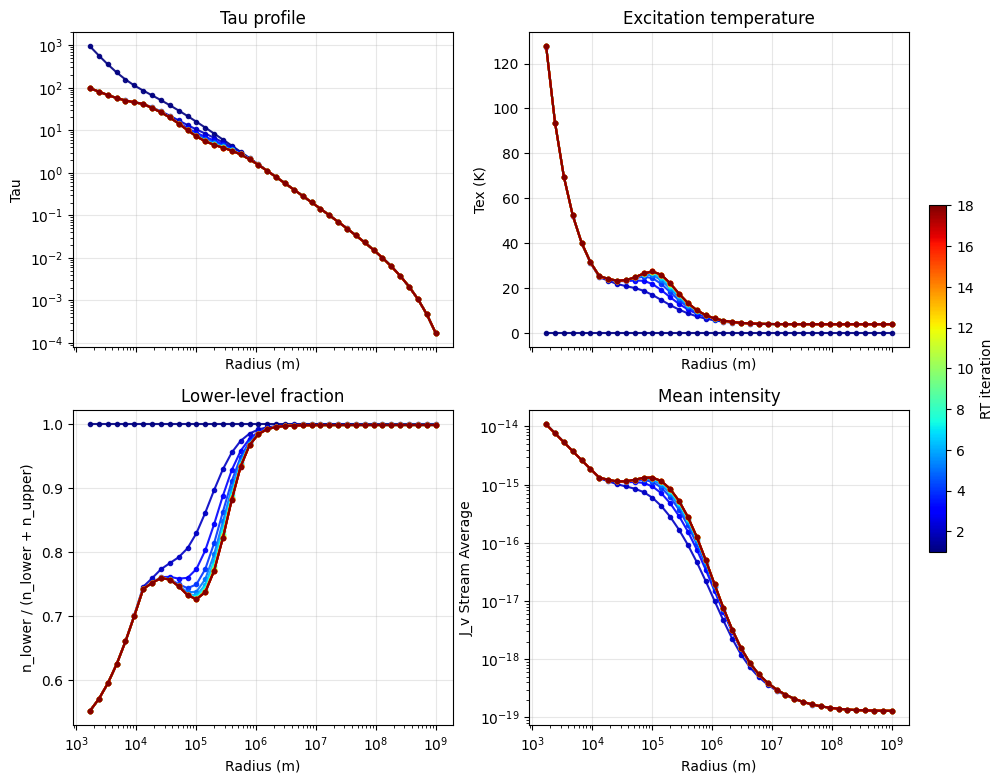

Final J_v_stream_average: [1.30190517e-19 1.30522642e-19 1.31182204e-19 1.32331344e-19
 1.34170380e-19 1.36961038e-19 1.41062735e-19 1.46983516e-19
 1.55453072e-19 1.67534875e-19 1.84814656e-19 2.09752223e-19
 2.46418738e-19 3.02201104e-19 3.92079983e-19 5.49976710e-19
 8.60009630e-19 1.54478259e-18 3.21839059e-18 7.60835448e-18
 1.94978633e-17 5.09701717e-17 1.26346586e-16 2.77757660e-16
 5.23732656e-16 8.42754657e-16 1.15145988e-15 1.32368871e-15
 1.31313593e-15 1.21493377e-15 1.14021147e-15 1.13385294e-15
 1.21374058e-15 1.31893996e-15 1.85698134e-15 2.63600466e-15
 3.75543735e-15 5.35273992e-15 7.61924191e-15 1.08232432e-14]
Final relative change: [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 6.50125417e-09 1.87705525e-07
 3.98408673e-06 3.81101381e-05 1.51

In [9]:

if history:
    fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True)
    ax0, ax1, ax2, ax3 = axes.flatten()

    iterations = np.array([item['iteration'] for item in history], dtype=int)
    norm = mpl.colors.Normalize(vmin=iterations.min(), vmax=iterations.max())
    cmap = plt.cm.jet

    for item in history:
        color = cmap(norm(item['iteration']))
        label = f"Iter {item['iteration']}"
        ax0.loglog(coma.xc, item['tau_profile'], color=color, marker='.', linewidth=1.5, alpha=0.9)
        ax1.semilogx(coma.xc, item['excitation_temperature_K'], color=color, marker='.', linewidth=1.5, alpha=0.9)
        ax2.semilogx(coma.xc, item['base_level_ratio'], color=color, marker='.', linewidth=1.5, alpha=0.9)
        if item['iteration'] == 1: continue
        jv_plot_floor = item.get('jv_floor_profile', np.full_like(item['J_v_stream_average'], jv_floor_tail))
        ax3.loglog(coma.xc, np.maximum(item['J_v_stream_average'], jv_plot_floor), color=color, marker='.', linewidth=1.5, alpha=0.9, label=label)

    for ax in (ax0, ax1, ax2, ax3):
        ax.grid(True, alpha=0.3)
        ax.set_xlabel('Radius (m)')

    ax0.set_ylabel('Tau')
    ax0.set_title('Tau profile')
    ax1.set_ylabel('Tex (K)')
    ax1.set_title('Excitation temperature')
    ax2.set_ylabel('n_lower / (n_lower + n_upper)')
    ax2.set_title('Lower-level fraction')
    ax3.set_ylabel('J_v Stream Average')
    ax3.set_title('Mean intensity')

    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes, pad=0.02, shrink=0.5)
    cbar.set_label('RT iteration')
    # cbar.set_position([0, 1])

    # plt.tight_layout()
    plt.show()

final_state = history[-1]
print('Final J_v_stream_average:', final_state['J_v_stream_average'])
print('Final relative change:', final_state['relative_change'])
print('Final n1/n0:', final_state['n_upper'] / np.maximum(final_state['n_lower'], 1.0e-300))


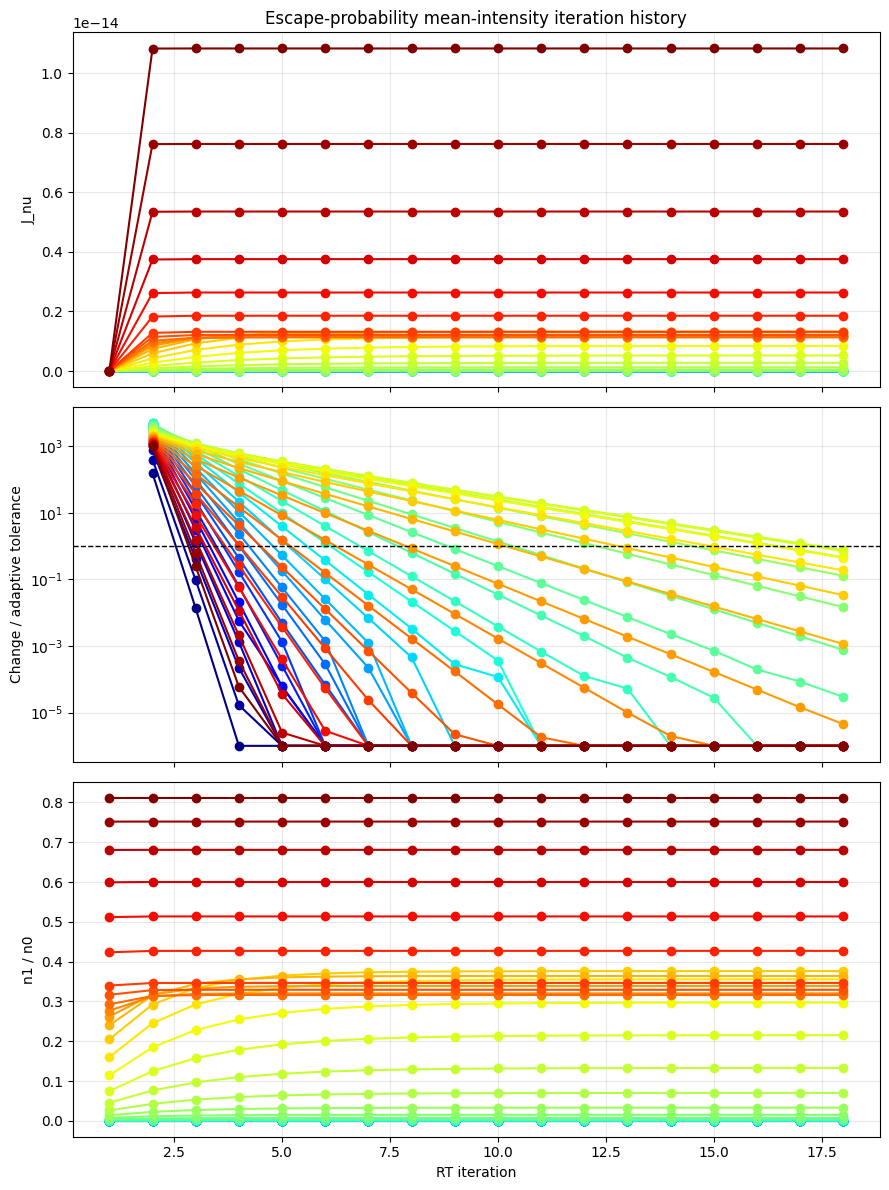

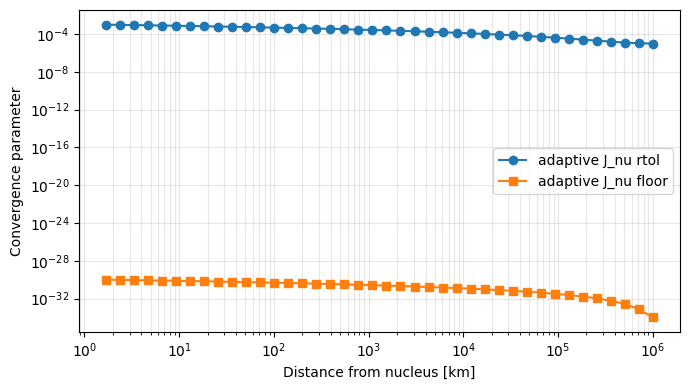

In [10]:
iterations = np.array([item['iteration'] for item in history], dtype=int)
jv_history = np.vstack([item['J_v_stream_average'] for item in history])
rel_history = np.vstack([item['relative_change'] for item in history])
normalized_change_history = np.vstack([item['normalized_change'] for item in history])
ratio_history = np.vstack([
    item['n_upper'] / np.maximum(item['n_lower'], 1.0e-300)
    for item in history
])

fig, axes = plt.subplots(3, 1, figsize=(9, 12), sharex=True)
norm = mpl.colors.Normalize(vmin=0, vmax=nlayer - 1)
cmap = plt.cm.jet

for layer in range(nlayer):
    color = cmap(norm(layer))
    axes[0].plot(iterations, jv_history[:, layer], marker='o', color=color)
    axes[1].semilogy(iterations, np.maximum(normalized_change_history[:, layer], 1.0e-6), marker='o', color=color)
    axes[2].plot(iterations, np.maximum(ratio_history[:, layer], 1.0e-30), marker='o', color=color)

axes[0].set_ylabel('J_nu')
axes[0].set_title('Escape-probability mean-intensity iteration history')
axes[1].axhline(1.0, color='k', linestyle='--', linewidth=1.0)
axes[1].set_ylabel('Change / adaptive tolerance')
axes[2].set_xlabel('RT iteration')
axes[2].set_ylabel('n1 / n0')
for ax in axes:
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
ax.loglog(coma.xc * 1.0e-3, jv_rtol_profile, marker='o', label='adaptive J_nu rtol')
ax.loglog(coma.xc * 1.0e-3, jv_floor_profile, marker='s', label='adaptive J_nu floor')
ax.set_xlabel('Distance from nucleus [km]')
ax.set_ylabel('Convergence parameter')
ax.grid(True, which='both', alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()



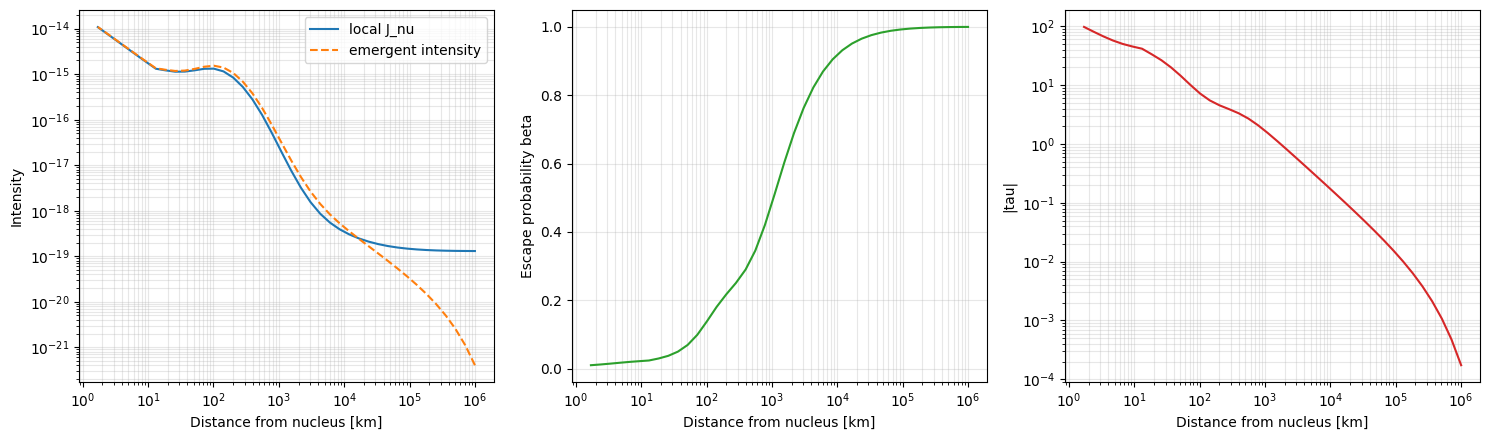

In [11]:
r_km = coma.xc * 1.0e-3
J_nu = np.asarray(final_state['J_v_stream_average'], dtype=np.float64)
beta = np.asarray(final_state['escape_probability'], dtype=np.float64)
emergent = np.asarray(final_state['emergent_intensity'], dtype=np.float64)
tau = np.asarray(final_state['tau_profile'], dtype=np.float64)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
axes[0].loglog(r_km, np.maximum(J_nu, 1.0e-300), label='local J_nu')
axes[0].loglog(r_km, np.maximum(emergent, 1.0e-300), '--', label='emergent intensity')
axes[0].set_ylabel('Intensity')
axes[0].legend()
axes[1].semilogx(r_km, beta, color='tab:green')
axes[1].set_ylabel('Escape probability beta')
axes[2].loglog(r_km, np.maximum(np.abs(tau), 1.0e-300), color='tab:red')
axes[2].set_ylabel('|tau|')
for ax in axes:
    ax.set_xlabel('Distance from nucleus [km]')
    ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()


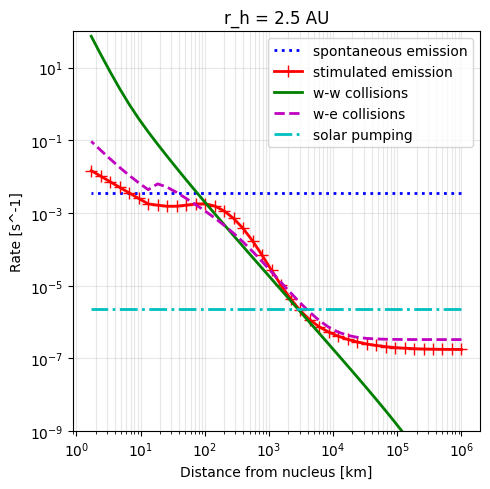

In [12]:
A_profile = np.broadcast_to(np.asarray(A_ul_s_1, dtype=np.float64), r_km.shape)
stimulated_profile = np.broadcast_to(np.asarray(B_ul_SI, dtype=np.float64), r_km.shape) * J_nu
Cm_profile = np.broadcast_to(np.asarray(Cm_ul_s_1, dtype=np.float64), r_km.shape)
Ce_profile = np.broadcast_to(np.asarray(Ce_ul_s_1, dtype=np.float64), r_km.shape)
G_profile = np.broadcast_to(np.asarray(G_ul_s_1, dtype=np.float64), r_km.shape)

fig, ax = plt.subplots(figsize=(5, 5))
ax.loglog(r_km, A_profile, 'b:', lw=2, label='spontaneous emission')
ax.loglog(r_km, stimulated_profile, 'r+-', lw=2, markersize=8, label='stimulated emission')
ax.loglog(r_km, Cm_profile, 'g-', lw=2, label='w-w collisions')
ax.loglog(r_km, Ce_profile, 'm--', lw=2, label='w-e collisions')
ax.loglog(r_km, G_profile, 'c-.', lw=2, label='solar pumping')
ax.set_ylim(1.0e-9, 1.0e2)
ax.set_xlabel('Distance from nucleus [km]')
ax.set_ylabel('Rate [s^-1]')
ax.set_title('r_h = 2.5 AU')
ax.grid(True, which='both', alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()
